# STalign: upstream PyTorch versus squidpy JAX

This notebook reproduces the upstream Xenium-to-Xenium example at the pinned STalign commit and runs squidpy's JAX port beside it. The moving sample is Xenium breast-cancer replicate 1; replicate 2 is the fixed reference.

The comparison covers the rasterised densities, aligned point clouds, warped densities, relative error, and landmark target-registration error (TRE). It is visual evidence, not a replacement for squidpy's stricter synthetic reference suite: real data includes the deliberately documented rasterisation and boundary-condition differences.

## Environment

Run the notebook from the `squidpy-ports` checkout in an environment containing this repository, a sibling editable `squidpy` checkout with its `jax` extra, and the documentation dependencies. For example:

```bash
uv pip install -e . -e ../squidpy[jax] ipykernel
JAX_ENABLE_X64=1 MPLBACKEND=agg jupyter lab docs/notebooks/stalign-xenium-comparison.ipynb
```

JAX x64 is a precondition because upstream STalign is float64 throughout. It is enabled through the process environment, never with `jax.config.update`, which is process-global.

In [1]:
from __future__ import annotations

import os
from pathlib import Path
from urllib.request import urlretrieve

if os.environ.get("JAX_ENABLE_X64") != "1":
    raise RuntimeError("Restart the kernel with JAX_ENABLE_X64=1; do not toggle JAX precision inside a live process.")

import anndata as ad
import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.interpolate import RegularGridInterpolator
from squidpy_ports.stalign import upstream

import squidpy as sq
from squidpy.experimental.methods.align_samples import StalignResult
from squidpy.experimental.methods.align_samples._stalign_impl._helpers import rasterize_cloud

assert jax.config.jax_enable_x64
torch.set_default_dtype(torch.float64)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
device = "cuda:0" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)
print(f"upstream={upstream.UPSTREAM_SHA[:8]}  torch={torch.__version__}  jax={jax.__version__}  device={device}")

/opt/squidpy-ports/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


upstream=b2068edc  torch=2.13.0+cu130  jax=0.11.0  device=cuda:0


## Download upstream's published inputs

The data remain under upstream's GPL-3.0 license and are downloaded from the pinned commit into the ignored documentation build directory. They are not copied into this repository.

In [2]:
ports_root = upstream.vendor_root().parents[1]
data_dir = ports_root / "docs" / "_build" / "stalign-data" / "xenium"
data_dir.mkdir(parents=True, exist_ok=True)

filenames = [
    "Xenium_FFPE_Human_Breast_Cancer_Rep1_cells.csv.gz",
    "Xenium_FFPE_Human_Breast_Cancer_Rep2_cells.csv.gz",
    "Xenium_Breast_Cancer_Rep1_points.npy",
    "Xenium_Breast_Cancer_Rep2_points.npy",
]
base_url = f"{upstream.UPSTREAM_URL}/raw/{upstream.UPSTREAM_SHA}/docs/xenium_data"
for filename in filenames:
    destination = data_dir / filename
    if not destination.exists():
        print(f"downloading {filename}")
        urlretrieve(f"{base_url}/{filename}", destination)

print(data_dir)

/opt/squidpy-ports/docs/_build/stalign-data/xenium


In [3]:
def load_landmarks(path: Path) -> np.ndarray:
    """Load upstream's annotation dictionary as a row-column array."""
    annotations = np.load(path, allow_pickle=True).tolist()
    return np.asarray([[annotations[key][0][1], annotations[key][0][0]] for key in annotations])


query_df = pd.read_csv(data_dir / filenames[0])
ref_df = pd.read_csv(data_dir / filenames[1])
query_xy = query_df[["x_centroid", "y_centroid"]].to_numpy()
ref_xy = ref_df[["x_centroid", "y_centroid"]].to_numpy()
query_landmarks_rc = load_landmarks(data_dir / filenames[2])
ref_landmarks_rc = load_landmarks(data_dir / filenames[3])
query_landmarks_xy = query_landmarks_rc[:, ::-1].copy()
ref_landmarks_xy = ref_landmarks_rc[:, ::-1].copy()

print(f"query cells={len(query_xy):,}; reference cells={len(ref_xy):,}; landmarks={len(ref_landmarks_xy)}")

query cells=167,782; reference cells=118,752; landmarks=3


## Rasterise with upstream

This follows `xenium-xenium-alignment.ipynb`: 30 µm pixels and the default blur. Passing `draw=0` avoids upstream's default four-value plotting return.

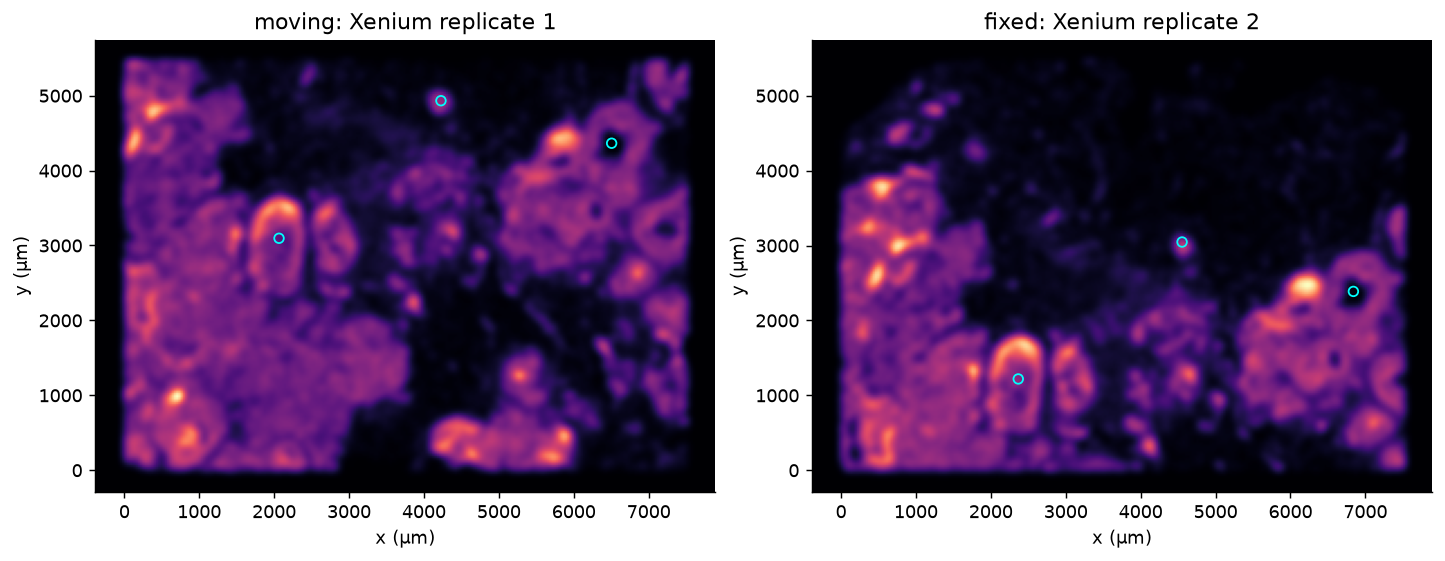

In [4]:
st = upstream.load()
x_query, y_query, density_query = st.rasterize(query_xy[:, 0], query_xy[:, 1], dx=30, draw=0)
x_ref, y_ref, density_ref = st.rasterize(ref_xy[:, 0], ref_xy[:, 1], dx=30, draw=0)
extent_query = st.extent_from_x((y_query, x_query))
extent_ref = st.extent_from_x((y_ref, x_ref))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)
for ax, image, extent, points, title in zip(
    axes,
    (density_query, density_ref),
    (extent_query, extent_ref),
    (query_landmarks_xy, ref_landmarks_xy),
    ("moving: Xenium replicate 1", "fixed: Xenium replicate 2"),
    strict=True,
):
    ax.imshow(np.asarray(image).squeeze(), extent=extent, cmap="magma")
    ax.scatter(points[:, 0], points[:, 1], s=28, facecolors="none", edgecolors="cyan")
    ax.set(title=title, xlabel="x (µm)", ylabel="y (µm)")
    ax.invert_yaxis()
plt.show()

## Fit both implementations

The parameters below are copied from upstream's Xenium notebook: `niter=300`, `sigmaM=1.5`, `sigmaB=1.0`, `sigmaA=1.1`, and `epV=100`. Both fits use the same annotated landmark pairs for affine initialisation. Upstream names the moving sample `I`; squidpy calls it the query.

In [5]:
fit_params = {"niter": 300, "sigmaM": 1.5, "sigmaB": 1.0, "sigmaA": 1.1, "epV": 100.0}
linear, translation = st.L_T_from_points(query_landmarks_rc, ref_landmarks_rc)
upstream_fit = st.LDDMM(
    [y_query, x_query],
    density_query,
    [y_ref, x_ref],
    density_ref,
    L=linear,
    T=translation,
    pointsI=query_landmarks_rc,
    pointsJ=ref_landmarks_rc,
    device=device,
    **fit_params,
)
plt.close("all")  # upstream draws unconditionally during optimisation

upstream_aligned_rc = st.transform_points_source_to_target(
    upstream_fit["xv"],
    upstream_fit["v"],
    upstream_fit["A"],
    np.ascontiguousarray(query_xy[:, ::-1]),
)
upstream_aligned_xy = upstream_aligned_rc.detach().cpu().numpy()[:, ::-1]

/opt/squidpy-ports/vendor/STalign/STalign/STalign.py:1301: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axE[2].set_yscale('log')


In [6]:
query = ad.AnnData(np.empty((len(query_xy), 0)), obsm={"spatial": query_xy})
reference = ad.AnnData(np.empty((len(ref_xy), 0)), obsm={"spatial": ref_xy})
squidpy_fit = sq.experimental.tl.align(
    reference,
    query,
    in_="obsm/spatial",
    by="obs",
    method="stalign",
    landmarks_source=query_landmarks_xy,
    landmarks_target=ref_landmarks_xy,
    dx=30.0,
    blur=1.0,
    raster_expand=1.1,
    **fit_params,
)
squidpy_aligned_xy = np.asarray(squidpy_fit.aligned_points)

## Warp the density images onto a common grid

A point-cloud fit normally does not expose a user image grid through `warp_image`: its density raster is an internal optimisation detail. For this diagnostic only, the next cell reconstructs those exact squidpy raster axes, attaches them to the fitted result, and samples the warped density onto upstream's fixed grid. This keeps the difference panel pixel-aligned.

In [7]:
upstream_warped = (
    st.transform_image_source_to_target(
        upstream_fit["xv"],
        upstream_fit["v"],
        upstream_fit["A"],
        [y_query, x_query],
        density_query,
        [y_ref, x_ref],
    )
    .detach()
    .cpu()
    .numpy()
    .squeeze()
)

query_axes, squidpy_query_density = rasterize_cloud(query_xy[:, ::-1], dx=30.0, blur=1.0, expand=1.1)
ref_axes, _ = rasterize_cloud(ref_xy[:, ::-1], dx=30.0, blur=1.0, expand=1.1)
squidpy_image_fit = StalignResult(
    affine=squidpy_fit.affine,
    velocity=squidpy_fit.velocity,
    velocity_grid=squidpy_fit.velocity_grid,
    aligned_points=squidpy_fit.aligned_points,
    query_axes=query_axes,
    ref_axes=ref_axes,
)
squidpy_warped = np.asarray(squidpy_image_fit.warp_image(squidpy_query_density)).squeeze()

onto_upstream_grid = RegularGridInterpolator(
    tuple(np.asarray(axis) for axis in ref_axes), squidpy_warped, bounds_error=False, fill_value=0.0
)
yy, xx = np.meshgrid(y_ref, x_ref, indexing="ij")
squidpy_warped_common = onto_upstream_grid(np.stack([yy, xx], axis=-1))


def unit_peak(image: np.ndarray) -> np.ndarray:
    """Scale an image to unit peak magnitude for visual comparison."""
    image = np.asarray(image, dtype=float)
    return image / max(float(np.max(np.abs(image))), np.finfo(float).tiny)


upstream_warped_norm = unit_peak(upstream_warped)
squidpy_warped_norm = unit_peak(squidpy_warped_common)
density_difference = np.abs(upstream_warped_norm - squidpy_warped_norm)

/opt/squidpy-ports/.venv/lib/python3.14/site-packages/torch/utils/_device.py:122: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


## Numerical agreement

The point error compares corresponding transformed cells. TRE measures the transformed annotated landmarks against their paired targets. Density error is measured after peak-normalising and resampling both warped densities onto upstream's fixed grid.

In [8]:
def relative_l2(actual: np.ndarray, expected: np.ndarray) -> float:
    """Return relative L2 error with a safe denominator."""
    denominator = max(float(np.linalg.norm(expected)), np.finfo(float).tiny)
    return float(np.linalg.norm(actual - expected) / denominator)


upstream_landmarks_xy = (
    st.transform_points_source_to_target(upstream_fit["xv"], upstream_fit["v"], upstream_fit["A"], query_landmarks_rc)
    .detach()
    .cpu()
    .numpy()[:, ::-1]
)
squidpy_landmarks_xy = np.asarray(squidpy_fit.transform(query_landmarks_xy))
upstream_tre = np.linalg.norm(upstream_landmarks_xy - ref_landmarks_xy, axis=1)
squidpy_tre = np.linalg.norm(squidpy_landmarks_xy - ref_landmarks_xy, axis=1)
point_delta = np.linalg.norm(upstream_aligned_xy - squidpy_aligned_xy, axis=1)

metrics = pd.Series(
    {
        "aligned points relative L2": relative_l2(squidpy_aligned_xy, upstream_aligned_xy),
        "aligned points median |Δ| (µm)": float(np.median(point_delta)),
        "aligned points p95 |Δ| (µm)": float(np.quantile(point_delta, 0.95)),
        "upstream landmark TRE mean (µm)": float(upstream_tre.mean()),
        "squidpy landmark TRE mean (µm)": float(squidpy_tre.mean()),
        "warped density relative L2": relative_l2(squidpy_warped_norm, upstream_warped_norm),
    },
    name="value",
).to_frame()
metrics

,value
aligned points relative L2,0.001623
aligned points median |Δ| (µm),1.859432
aligned points p95 |Δ| (µm),21.607669
upstream landmark TRE mean (µm),28.565448
squidpy landmark TRE mean (µm),27.628431
warped density relative L2,0.042663


## Side-by-side result

The upper row compares warped densities. The lower row overlays a deterministic sample of transformed moving cells on the fixed sample; the difference panel colours each sampled cell by the distance between the two implementations.

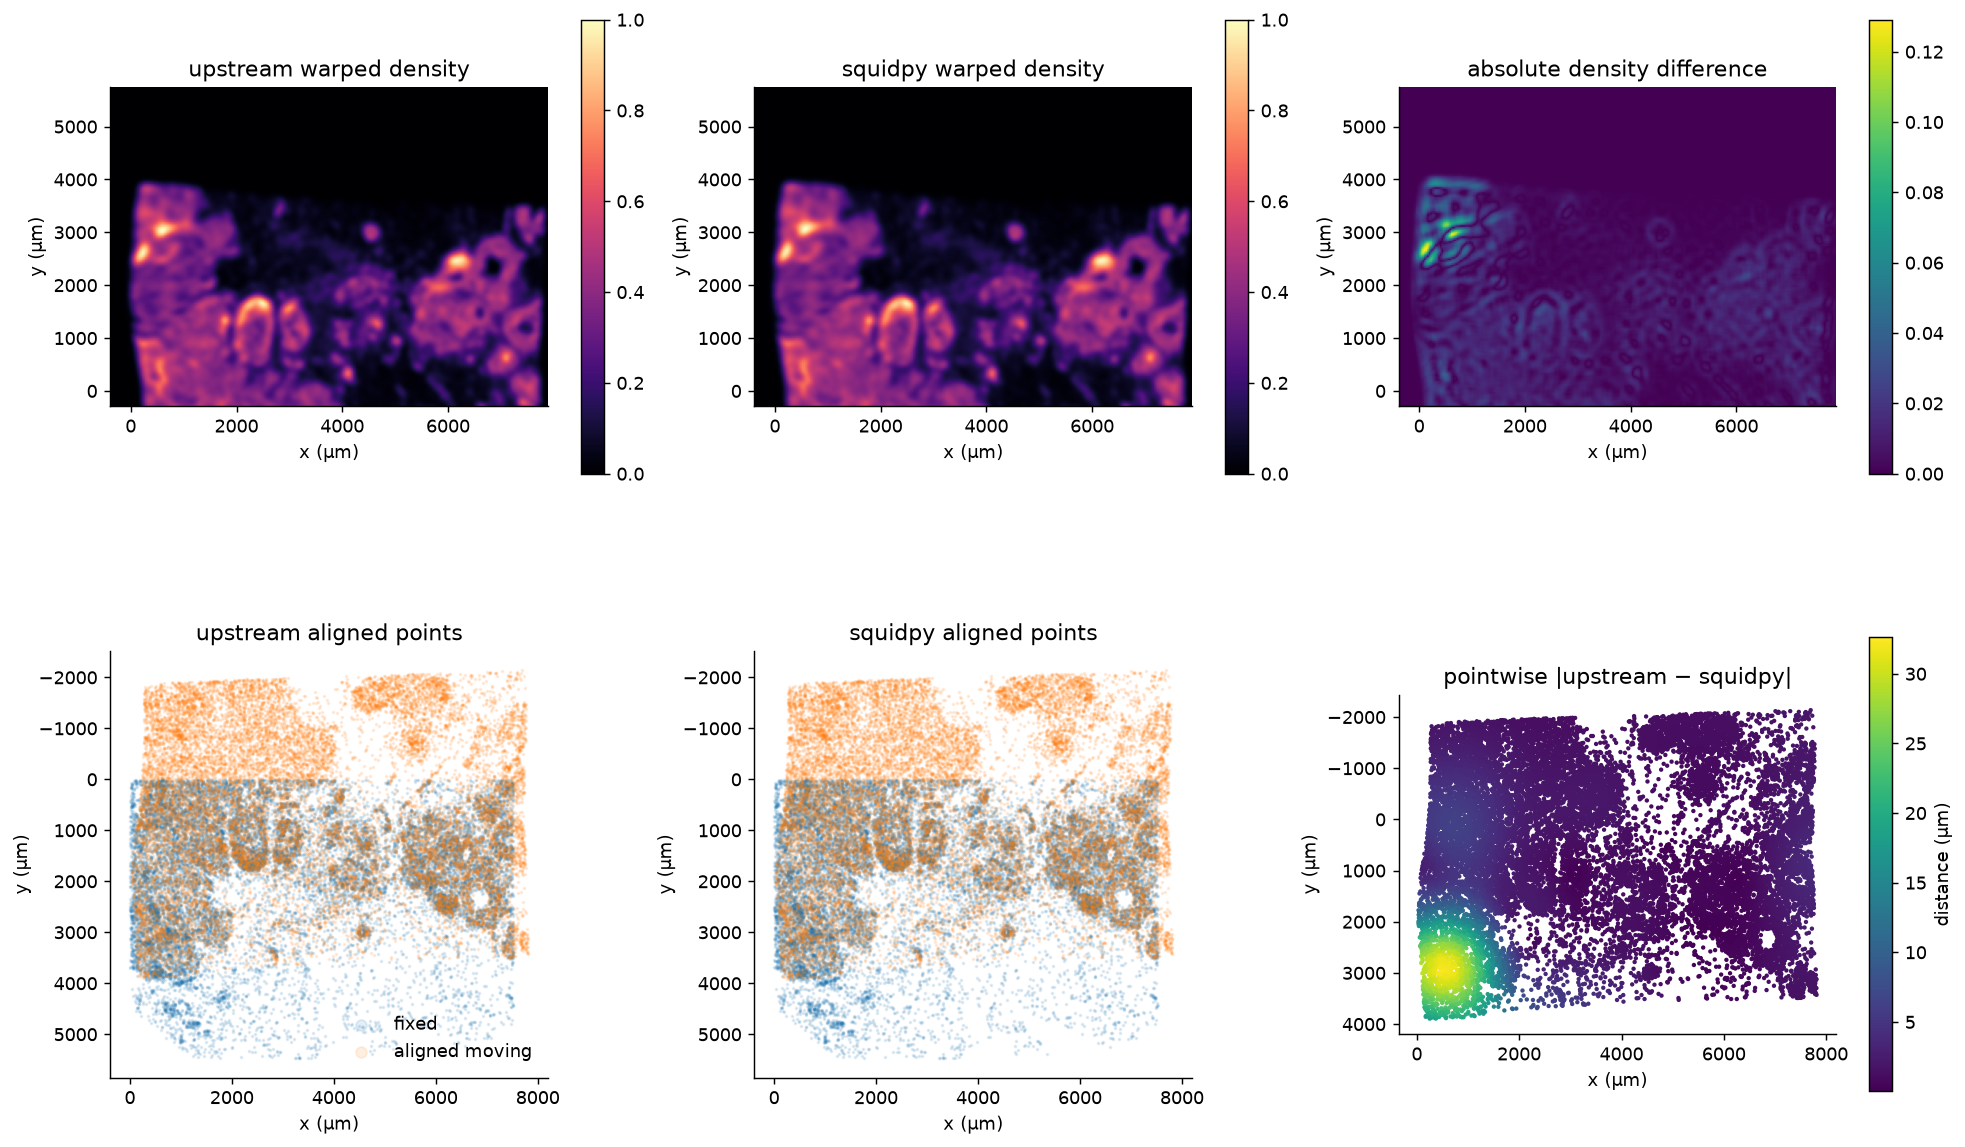

In [9]:
rng = np.random.default_rng(0)
sample = np.sort(rng.choice(len(query_xy), size=min(20_000, len(query_xy)), replace=False))
fixed_sample = np.sort(rng.choice(len(ref_xy), size=min(20_000, len(ref_xy)), replace=False))

fig, axes = plt.subplots(2, 3, figsize=(15, 9.5), constrained_layout=True)
image_panels = (
    (upstream_warped_norm, "upstream warped density", "magma"),
    (squidpy_warped_norm, "squidpy warped density", "magma"),
    (density_difference, "absolute density difference", "viridis"),
)
for ax, (image, title, cmap) in zip(axes[0], image_panels, strict=True):
    artist = ax.imshow(image, extent=extent_ref, cmap=cmap)
    ax.set(title=title, xlabel="x (µm)", ylabel="y (µm)")
    ax.invert_yaxis()
    fig.colorbar(artist, ax=ax, shrink=0.75)

for ax, aligned, title in zip(
    axes[1, :2],
    (upstream_aligned_xy, squidpy_aligned_xy),
    ("upstream aligned points", "squidpy aligned points"),
    strict=True,
):
    ax.scatter(ref_xy[fixed_sample, 0], ref_xy[fixed_sample, 1], s=1, alpha=0.12, label="fixed")
    ax.scatter(aligned[sample, 0], aligned[sample, 1], s=1, alpha=0.12, label="aligned moving")
    ax.set(title=title, xlabel="x (µm)", ylabel="y (µm)", aspect="equal")
    ax.invert_yaxis()
axes[1, 0].legend(markerscale=6, frameon=False)

delta_artist = axes[1, 2].scatter(
    upstream_aligned_xy[sample, 0],
    upstream_aligned_xy[sample, 1],
    c=point_delta[sample],
    s=2,
    cmap="viridis",
)
axes[1, 2].set(title="pointwise |upstream − squidpy|", xlabel="x (µm)", ylabel="y (µm)", aspect="equal")
axes[1, 2].invert_yaxis()
fig.colorbar(delta_artist, ax=axes[1, 2], label="distance (µm)", shrink=0.75)
plt.show()

## Reading the differences

Small but non-zero whole-dataset differences are expected. Squidpy bilinearly deposits points and conserves mass at image borders, while the pinned upstream rasteriser snaps deposits and loses some border mass. Upstream also samples outside the velocity grid with zero padding; squidpy uses the continuous border extension. Finally, upstream returns the affine from the start of its last iteration, while squidpy returns the post-update affine.

The synthetic reference suite isolates these effects and applies strict expected-failure checks to the intentional divergences. See `STALIGN_DIVERGENCES.md` in squidpy's reference-test directory for the measured ledger.

In [10]:
try:
    from watermark import watermark as _watermark

    print(_watermark(packages="squidpy,squidpy_ports,jax,jaxlib,torch", python=True, machine=True))
except Exception as _exc:  # noqa: BLE001 - a version stamp must never fail the run
    print(f"watermark unavailable: {_exc}")

Python implementation: CPython
Python version       : 3.14.7
IPython version      : 9.16.1

squidpy      : 1.8.3.dev0
squidpy_ports: 0.0.1
jax          : 0.11.0
jaxlib       : 0.11.0
torch        : 2.13.0

Compiler    : Clang 22.1.3 
OS          : Linux
Release     : 5.14.0-570.25.1.el9_6.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 224
Architecture: 64bit

